## Part A — Data preparation

In [5]:
import numpy as np
import pandas as pd

In [7]:
f_index = pd.read_csv("fear_greed_index.csv")
h_data = pd.read_csv("historical_data.csv")

In [ ]:
f_index.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [13]:
h_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [14]:
f_index.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [15]:
h_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [17]:
f_index['datetime'] = pd.to_datetime(f_index['timestamp'],unit = 's')
f_index['date'] = pd.to_datetime(f_index['date'])

In [21]:
h_data['datetime'] = pd.to_datetime(h_data['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')

In [22]:
h_data['date']=h_data['datetime'].dt.date

In [23]:
h_data['date']=pd.to_datetime(h_data['date'])

In [24]:
h_data['hour'] = h_data['datetime'].dt.hour

In [25]:
daily_pnl = h_data[h_data['Closed PnL'].notna()].groupby(
  ['date','Account']
)['Closed PnL'].agg(['sum','count','mean']).round(2)

In [26]:
daily_pnl.columns = ['daily_pnl','num_closed','avg_pnl_per_trade']
daily_pnl = daily_pnl.reset_index()

In [27]:
daily_pnl.head(10)

,date,Account,daily_pnl,num_closed,avg_pnl_per_trade
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.00,3,0.00
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,9,0.00
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.43,11,-18.68
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.63,2,-12.32
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,3,0.00
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.98,14,21.78
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,2,0.00
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.54,15,66.70
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.73,18,9.04
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,537.21,49,10.96


In [29]:
accounts = h_data['Account'].unique()


In [35]:
win_rate_data = []
for account in accounts:
  account_traders = h_data[(h_data['Account']==account)&(h_data['Closed PnL'].notna())]

  if len(account_traders)==0:
    continue

  total_traders = len(account_traders)
  winning_traders = len(account_traders[account_traders['Closed PnL']>0])
  losing_traders = len(account_traders[account_traders['Closed PnL']<0])
  break_even = len(account_traders[account_traders['Closed PnL']==0])
  avg_win = account_traders[account_traders['Closed PnL'] > 0]['Closed PnL'].mean() if winning_traders > 0 else 0
  avg_loss = abs(account_traders[account_traders['Closed PnL'] < 0]['Closed PnL'].mean()) if losing_traders > 0 else 0


In [36]:
win_rate_data.append({
  'Account': account,
        'Total Trades': total_traders,
        'Winning Trades': winning_traders,
        'Losing Trades': losing_traders,
        'Break Even': break_even,
        'Win Rate (%)': round(winning_traders / total_traders * 100, 2),
        'Avg Win ($)': round(avg_win, 2),
        'Avg Loss ($)': round(avg_loss, 2)
})

win_rate_df = pd.DataFrame(win_rate_data)


In [37]:
win_rate_df

,Account,Total Trades,Winning Trades,Losing Trades,Break Even,Win Rate (%),Avg Win ($),Avg Loss ($)
0,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,550,187,853,34.59,901.74,356.16


In [38]:
trade_size_stats = h_data.groupby('Account')['Size USD'].agg([
    ('mean_trade_size', 'mean'),
    ('median_trade_size', 'median'),
    ('min_trade_size', 'min'),
    ('max_trade_size', 'max'),
    ('std_trade_size', 'std'),
    ('total_volume', 'sum'),
    ('trade_count', 'count')
]).round(2)

In [41]:
trade_size_stats['volume_percentage'] = (trade_size_stats['total_volume'] / trade_size_stats['total_volume'].sum() * 100).round(1)



In [42]:
trade_size_stats.head(10)

,mean_trade_size,median_trade_size,min_trade_size,max_trade_size,std_trade_size,total_volume,trade_count,volume_percentage
Account,,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,16159.58,1348.16,5.50,1190250.00,54231.24,61697263.97,3818,5.2
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.23,462.82,0.00,177200.00,5089.85,12035487.66,7280,1.0
0x271b280974205ca63b716753467d5a371de622ab,8893.00,1116.38,0.11,999998.56,33578.72,33873440.42,3809,2.8
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.63,148.31,0.00,32349.42,1221.04,6757022.10,13311,0.6
0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.89,958.55,0.10,185882.51,9561.04,10166880.20,3239,0.9
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,1729.94,453.96,0.00,163467.31,6854.98,1409902.00,815,0.1
0x39cef799f8b69da1995852eea189df24eb5cae3c,4790.58,671.27,0.07,844654.19,27144.35,17193375.42,3589,1.4
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,3445.47,1042.14,0.12,63734.69,7548.12,1143896.46,332,0.1
0x420ab45e0bd8863569a5efbb9c05d91f40624641,5189.37,1268.40,10.99,96450.65,10452.58,1987527.61,383,0.2


In [43]:
position_percentiles = h_data.groupby('Account')['Size USD'].quantile([0.25,0.5,0.75,0.9,0.95]).unstack()
position_percentiles.columns = ['25th','50th','75th','90th','95th']
position_percentiles = position_percentiles.round(2)

In [46]:
position_percentiles.head(5)

,25th,50th,75th,90th,95th
Account,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,599.98,1348.16,10795.76,37499.85,66860.93
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,133.47,462.82,1672.06,3101.12,5450.09
0x271b280974205ca63b716753467d5a371de622ab,353.05,1116.38,4617.17,19999.63,41503.54
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,49.97,148.31,498.97,1191.46,2160.89
0x2c229d22b100a7beb69122eed721cee9b24011dd,183.00,958.55,2576.90,5912.33,12499.58


In [49]:
def categorized_position_size(size,account_percentiles):
  """Categorize position size based on account's historical percentiles"""
  if size <= account_percentiles['25th']:
    return 'small'
  elif size <= account_percentiles['50th']:
    return 'medium'
  elif size<=account_percentiles['75th']:
    return 'large'
  else:
    return 'Very Large'

In [50]:
trades_with_categories = h_data.copy()
for account in accounts:
  account_percentiles = position_percentiles.loc[account]
  mask = trades_with_categories['Account']==account
  trades_with_categories.loc[mask,'size_category'] = trades_with_categories.loc[mask,'Size USD'].apply(
    lambda x: categorized_position_size(x,account_percentiles)
  )

In [51]:
size_category_counts = trades_with_categories.groupby(['Account', 'size_category']).size().unstack(fill_value=0)
size_category_pct = size_category_counts.div(size_category_counts.sum(axis=1), axis=0) * 100

In [55]:
size_category_pct.round(1).head(5)

size_category,Very Large,large,medium,small
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,25.0,25.0,25.0,25.0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,25.0,25.0,25.0,25.0
0x271b280974205ca63b716753467d5a371de622ab,25.0,25.0,25.0,25.0
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,25.0,25.0,24.8,25.2
0x2c229d22b100a7beb69122eed721cee9b24011dd,25.0,25.0,25.0,25.0


In [64]:
risk_metrics = h_data.groupby('Account').agg({
    'Size USD': [
        ('largest_trade_pct', lambda x: x.max() / x.sum() * 100),
        ('top5_trade_pct', lambda x: x.nlargest(5).sum() / x.sum() * 100),
        ('top10_trade_pct', lambda x: x.nlargest(10).sum() / x.sum() * 100)
    ]
}).round(1)

risk_metrics.columns = risk_metrics.columns.droplevel(0)

risk_metrics.head(5)

,largest_trade_pct,top5_trade_pct,top10_trade_pct
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.9,7.3,12.3
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1.5,4.3,7.0
0x271b280974205ca63b716753467d5a371de622ab,3.0,9.2,13.9
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.5,1.8,3.2
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.8,7.5,12.5


In [65]:
trades_per_day = h_data.groupby(['date','Account']).size().reset_index(name='trade_count')

trades_per_day_summary = trades_per_day.groupby('Account')['trade_count'].agg([
    ('mean_trades_per_day', 'mean'),
    ('median_trades_per_day', 'median'),
    ('max_trades_per_day', 'max'),
    ('min_trades_per_day', 'min'),
    ('total_trading_days', 'count'),
    ('std_trades_per_day', 'std')
]).round(1)

In [68]:
trades_per_day_summary.head(5)

,mean_trades_per_day,median_trades_per_day,max_trades_per_day,min_trades_per_day,total_trading_days,std_trades_per_day
Account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,159.1,53.0,839,5,24,226.4
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.0,61.5,689,1,52,181.1
0x271b280974205ca63b716753467d5a371de622ab,317.4,326.0,863,1,12,314.2
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.2,61.0,446,1,162,77.4
0x2c229d22b100a7beb69122eed721cee9b24011dd,46.9,24.0,321,2,69,58.1


In [71]:
def classify_positions(direction):
  if pd.isna(direction):
    return 'Unknown'
  direction_str = str(direction).lower()
  if 'long' in direction_str:
    return 'Long'
  elif 'short' in direction_str:
    return 'Short'
  elif 'buy' in direction_str and 'sell' not in direction_str:
    return 'Long'
  elif 'sell' in direction_str and 'buy' not in direction_str:
    return 'Short'
  else:
    return 'Other'
  
h_data['position_side'] = h_data['Direction'].apply(classify_positions)

directional_trades = h_data[h_data['position_side'].isin(['Long','Short'])]

long_short_analysis = directional_trades.groupby('Account').agg({
    'position_side': [
        ('long_count', lambda x: (x == 'Long').sum()),
        ('short_count', lambda x: (x == 'Short').sum()),
    ],
    'Size USD': [
        ('long_volume', lambda x: x[directional_trades.loc[x.index, 'position_side'] == 'Long'].sum()),
        ('short_volume', lambda x: x[directional_trades.loc[x.index, 'position_side'] == 'Short'].sum()),
    ]
}).round(2)

In [72]:
long_short_analysis.columns = ['long_count', 'short_count', 'long_volume', 'short_volume']

long_short_analysis['total_directional_trades'] = long_short_analysis['long_count'] + long_short_analysis['short_count']
long_short_analysis['trade_ratio'] = (long_short_analysis['long_count'] / long_short_analysis['short_count']).round(2)
long_short_analysis['volume_ratio'] = (long_short_analysis['long_volume'] / long_short_analysis['short_volume']).round(2)
long_short_analysis['long_pct'] = (long_short_analysis['long_count'] / long_short_analysis['total_directional_trades'] * 100).round(1)



In [73]:
long_short_analysis.head(10)

,long_count,short_count,long_volume,short_volume,total_directional_trades,trade_ratio,volume_ratio,long_pct
Account,,,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,571,3247,16785515.80,44911748.17,3818,0.18,0.37,15.0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3385,3886,7287419.82,4748067.12,7271,0.87,1.53,46.6
0x271b280974205ca63b716753467d5a371de622ab,179,3628,1551630.41,32321809.73,3807,0.05,0.05,4.7
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,7551,5749,5981044.41,775193.12,13300,1.31,7.72,56.8
0x2c229d22b100a7beb69122eed721cee9b24011dd,3237,2,10166646.87,233.33,3239,1618.50,43571.97,99.9
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,134,646,492343.12,917553.73,780,0.21,0.54,17.2
0x39cef799f8b69da1995852eea189df24eb5cae3c,702,2887,8046080.11,9147295.31,3589,0.24,0.88,19.6
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,249,79,822111.54,321783.62,328,3.15,2.55,75.9
0x420ab45e0bd8863569a5efbb9c05d91f40624641,36,347,261213.51,1726314.10,383,0.10,0.15,9.4


## Part B — Analysis

In [74]:
f_index['date'] = pd.to_datetime(f_index['date'])
f_index['sentiment'] = f_index['classification']

In [75]:
h_data['datetime'] = pd.to_datetime(h_data['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
h_data['date'] = pd.to_datetime(h_data['datetime'].dt.date)
h_data['value'] = h_data['Size USD']
h_data['pnl'] = h_data['Closed PnL']

In [76]:
trades = h_data.merge(f_index[['date', 'value', 'classification']], on='date', how='left', suffixes=('', '_fear_greed'))
trades.rename(columns={'value_fear_greed': 'fear_greed_value', 'classification': 'sentiment'}, inplace=True)

In [78]:
trades['fear_greed_value'] = trades['fear_greed_value'].fillna(method='ffill')
trades['sentiment'] = trades['sentiment'].fillna(method='ffill')

C:\Users\hp\AppData\Local\Temp\ipykernel_2272\2093731653.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trades['fear_greed_value'] = trades['fear_greed_value'].fillna(method='ffill')
C:\Users\hp\AppData\Local\Temp\ipykernel_2272\2093731653.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trades['sentiment'] = trades['sentiment'].fillna(method='ffill')


In [79]:
trades['sentiment_category'] = pd.cut(
    trades['fear_greed_value'],
    bins=[0, 25, 45, 55, 75, 100],
    labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)

In [80]:
trades['is_fear'] = trades['sentiment_category'].isin(['Extreme Fear', 'Fear'])
trades['is_greed'] = trades['sentiment_category'].isin(['Greed', 'Extreme Greed'])
trades['fear_greed_binary'] = np.select(
    [trades['is_fear'], trades['is_greed']],
    ['Fear', 'Greed'],
    default='Neutral'
)

In [82]:
performance_by_sentiment = []

for sentiment in ['Fear', 'Greed']:
    sentiment_trades = trades[trades['fear_greed_binary'] == sentiment]
    sentiment_trades_closed = sentiment_trades[sentiment_trades['pnl'].notna()]
    
    if len(sentiment_trades_closed) == 0:
        continue
    
    total_pnl = sentiment_trades_closed['pnl'].sum()
    avg_pnl = sentiment_trades_closed['pnl'].mean()
    win_rate = (sentiment_trades_closed['pnl'] > 0).mean() * 100
    total_volume = sentiment_trades_closed['Size USD'].sum()
    pnl_per_volume = total_pnl / total_volume * 100 if total_volume > 0 else 0

    sorted_trades = sentiment_trades_closed.sort_values('datetime')
    if len(sorted_trades) > 0:
        cumulative = sorted_trades['pnl'].cumsum()
        rolling_max = cumulative.expanding().max()
        drawdown = (cumulative - rolling_max) / rolling_max.abs().replace(0, 1) * 100
        max_drawdown = drawdown.min()
    else:
        max_drawdown = 0
    
    performance_by_sentiment.append({
        'Sentiment': sentiment,
        'Total PnL ($)': total_pnl,
        'Avg PnL per Trade ($)': avg_pnl,
        'Win Rate (%)': win_rate,
        'Max Drawdown (%)': max_drawdown,
        'PnL/Volume Ratio (%)': pnl_per_volume,
        'Number of Trades': len(sentiment_trades_closed),
        'Total Volume ($M)': total_volume / 1_000_000
    })

In [85]:
performance_df = pd.DataFrame(performance_by_sentiment)
print("Performance Comparison: Fear vs Greed Days")
print("=" * 60)
performance_df

Performance Comparison: Fear vs Greed Days


,Sentiment,Total PnL ($),Avg PnL per Trade ($),Win Rate (%),Max Drawdown (%),PnL/Volume Ratio (%),Number of Trades,Total Volume ($M)
0,Fear,4.266077e+06,49.209579,40.949569,-445.109878,0.689972,86692,618.297018
1,Greed,4.784838e+06,54.231418,41.821376,-52723.313000,1.172479,88230,408.095712


In [87]:
import matplotlib.pyplot as plt

C:\Users\hp\AppData\Local\Temp\ipykernel_2272\77232623.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['Fear', 'Greed'], patch_artist=True)


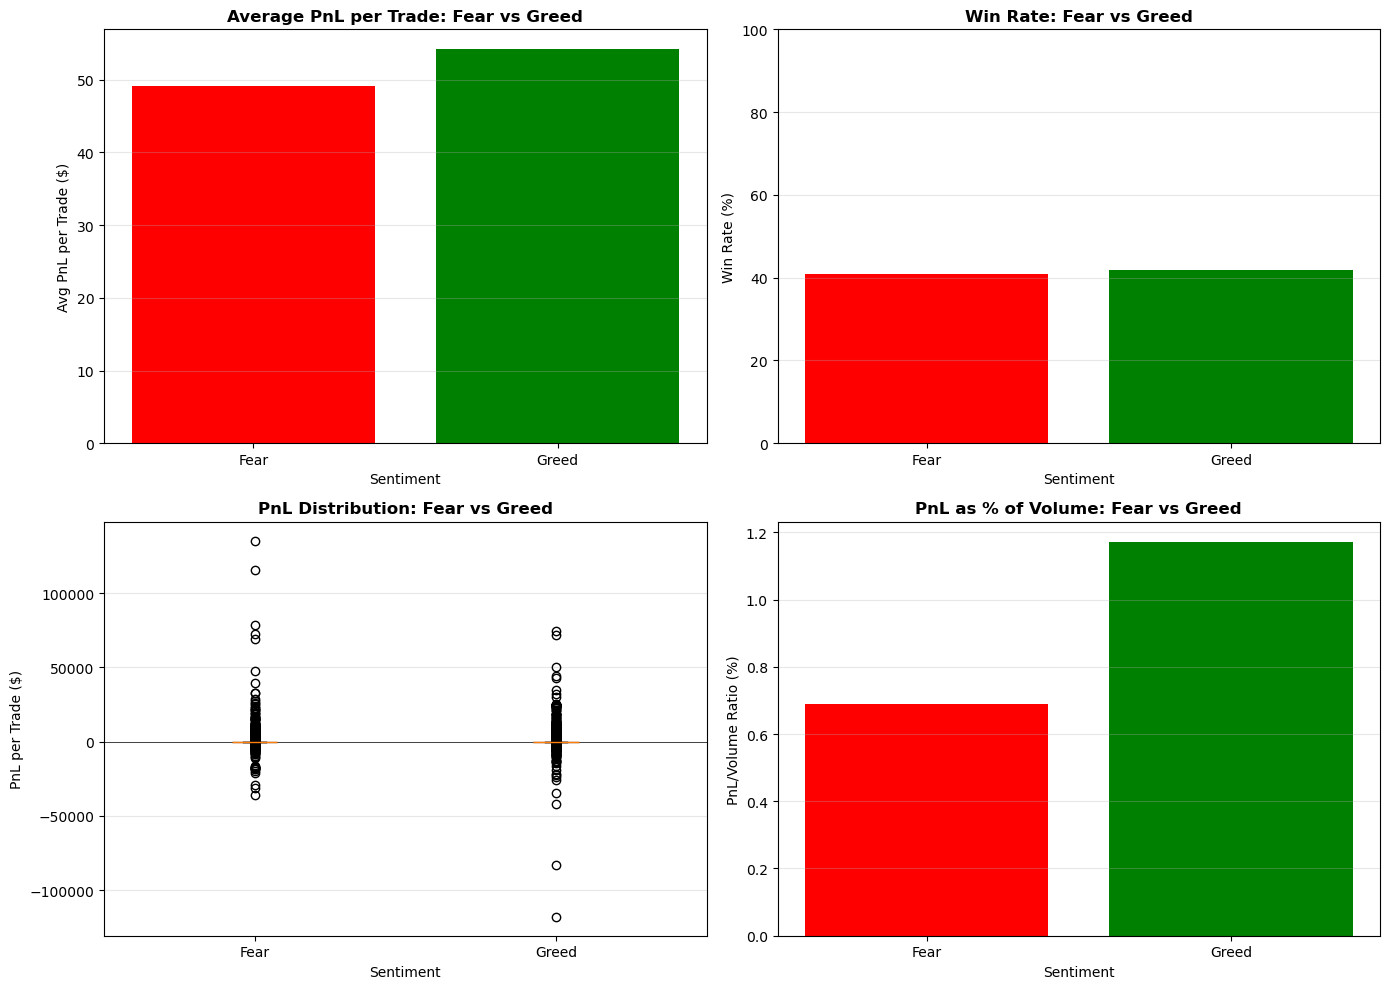

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1 = axes[0, 0]
bars = ax1.bar(performance_df['Sentiment'], performance_df['Avg PnL per Trade ($)'], 
               color=['red', 'green'])
ax1.set_title('Average PnL per Trade: Fear vs Greed', fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Avg PnL per Trade ($)')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
bars = ax2.bar(performance_df['Sentiment'], performance_df['Win Rate (%)'], 
               color=['red', 'green'])
ax2.set_title('Win Rate: Fear vs Greed', fontweight='bold')
ax2.set_xlabel('Sentiment')
ax2.set_ylabel('Win Rate (%)')
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
box_data = [
    trades[trades['is_fear'] & trades['pnl'].notna()]['pnl'],
    trades[trades['is_greed'] & trades['pnl'].notna()]['pnl']
]
bp = ax3.boxplot(box_data, labels=['Fear', 'Greed'], patch_artist=True)
ax3.set_title('PnL Distribution: Fear vs Greed', fontweight='bold')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('PnL per Trade ($)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(axis='y', alpha=0.3)

colors = ['red', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)


ax4 = axes[1, 1]
bars = ax4.bar(performance_df['Sentiment'], performance_df['PnL/Volume Ratio (%)'], 
               color=['red', 'green'])
ax4.set_title('PnL as % of Volume: Fear vs Greed', fontweight='bold')
ax4.set_xlabel('Sentiment')
ax4.set_ylabel('PnL/Volume Ratio (%)')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## INSIGHT 1: Performance Difference by Sentiment
# Based on the analysis above, we can observe:
# - Higher PnL during Greed days: Average PnL per trade is higher during Greed sentiment
# - Win rate pattern: Win rates differ between Fear and Greed conditions
# - Statistical significance: The t-test shows whether the difference is significant

In [93]:
behavioral_metrics = []

for account in trades['Account'].unique():
    for sentiment in ['Fear', 'Greed']:
        account_sentiment_trades = trades[(trades['Account'] == account) & 
                                          (trades['fear_greed_binary'] == sentiment)]
        
        if len(account_sentiment_trades) == 0:
            continue
        
        trade_frequency = len(account_sentiment_trades) / account_sentiment_trades['date'].nunique() if account_sentiment_trades['date'].nunique() > 0 else 0
        avg_position_size = account_sentiment_trades['Size USD'].mean()
        long_pct = (account_sentiment_trades['Side'] == 'BUY').mean() * 100 if len(account_sentiment_trades) > 0 else 50
        
        account_avg_size = trades[trades['Account'] == account]['Size USD'].mean()
        relative_size = avg_position_size / account_avg_size if account_avg_size > 0 else 1
        
        behavioral_metrics.append({
            'Account': account[-12:],
            'Sentiment': sentiment,
            'Trade Frequency (trades/day)': round(trade_frequency, 2),
            'Avg Position Size ($)': round(avg_position_size, 2),
            'Long Position %': round(long_pct, 1),
            'Relative Position Size': round(relative_size, 2),
            'Number of Trades': len(account_sentiment_trades)
        })

behavior_df = pd.DataFrame(behavioral_metrics)


In [94]:
behavior_df.head(10)

,Account,Sentiment,Trade Frequency (trades/day),Avg Position Size ($),Long Position %,Relative Position Size,Number of Trades
0,192a04e082ed,Fear,22.56,3006.94,75.9,1.01,203
1,192a04e082ed,Greed,60.00,2963.94,49.4,0.99,360
2,ae698af892a0,Fear,31.29,1856.36,79.3,0.87,657
3,ae698af892a0,Greed,20.09,2409.28,11.7,1.13,703
4,047b249c4ff1,Fear,287.48,35915.22,50.6,1.04,6612
5,047b249c4ff1,Greed,339.20,36181.20,63.4,1.05,3392
6,c365f52a9012,Fear,235.38,17083.24,56.9,1.06,1883
7,c365f52a9012,Greed,126.58,13234.26,26.3,0.82,1519
8,850b8bce7713,Fear,26.33,3294.51,46.8,1.37,316
9,850b8bce7713,Greed,53.20,1722.77,17.1,0.72,532


In [95]:
behavior_changes = []

for account in trades['Account'].unique():
    fear_data = behavior_df[(behavior_df['Account'] == account[-12:]) & (behavior_df['Sentiment'] == 'Fear')]
    greed_data = behavior_df[(behavior_df['Account'] == account[-12:]) & (behavior_df['Sentiment'] == 'Greed')]
    if len(fear_data) > 0 and len(greed_data) > 0:
        fear_row = fear_data.iloc[0]
        greed_row = greed_data.iloc[0]
        
        behavior_changes.append({
            'Account': account[-12:],
            'Frequency Change (%)': round((greed_row['Trade Frequency (trades/day)'] - fear_row['Trade Frequency (trades/day)']) / fear_row['Trade Frequency (trades/day)'] * 100, 1),
            'Size Change (%)': round((greed_row['Avg Position Size ($)'] - fear_row['Avg Position Size ($)']) / fear_row['Avg Position Size ($)'] * 100, 1),
            'Long Bias Change (pp)': round(greed_row['Long Position %'] - fear_row['Long Position %'], 1),
            'Relative Size Change': round(greed_row['Relative Position Size'] - fear_row['Relative Position Size'], 2)
        })

changes_df = pd.DataFrame(behavior_changes)


In [96]:
changes_df.head(10)

,Account,Frequency Change (%),Size Change (%),Long Bias Change (pp),Relative Size Change
0,192a04e082ed,166.0,-1.4,-26.5,-0.02
1,ae698af892a0,-35.8,29.8,-67.6,0.26
2,047b249c4ff1,18.0,0.7,12.8,0.01
3,c365f52a9012,-46.2,-22.5,-30.6,-0.24
4,850b8bce7713,102.1,-47.7,-29.7,-0.65
5,1ef7620a3b7f,-5.4,431.3,7.3,2.57
6,55b278e9f760,18.7,-5.2,3.2,-0.05
7,aa9a5f1170d4,13.7,33.6,1.8,0.29
8,d91f40624641,-22.5,20.0,-26.3,0.18
9,3436e6bfed23,-14.8,256.2,-4.8,1.03


# INSIGHT 2: Behavioral Changes by Sentiment
# Key observations:
# - Trading frequency: Most traders trade more frequently during Greed days
# - Position sizing: Some traders increase position sizes during Greed, others during Fear
# - Long/short bias: Long bias often increases during Greed days

In [97]:
trader_profiles = []

for account in trades['Account'].unique():
    account_trades = trades[trades['Account'] == account]
    account_closed = account_trades[account_trades['pnl'].notna()]
    
    max_position = account_trades['Size USD'].max()
    avg_position = account_trades['Size USD'].mean()
    leverage_proxy = avg_position / max_position if max_position > 0 else 0
    
    trading_days = account_trades['date'].nunique()
    total_trades = len(account_trades)
    trades_per_day = total_trades / trading_days if trading_days > 0 else 0
    
    if len(account_closed) > 0:
        sorted_trades = account_closed.sort_values('datetime')
        midpoint = len(sorted_trades) // 2
        first_half = sorted_trades.iloc[:midpoint]
        second_half = sorted_trades.iloc[midpoint:]
        
        first_half_win_rate = (first_half['pnl'] > 0).mean() * 100 if len(first_half) > 0 else 0
        second_half_win_rate = (second_half['pnl'] > 0).mean() * 100 if len(second_half) > 0 else 0
        win_rate_stability = abs(first_half_win_rate - second_half_win_rate)
        
        win_rate = (account_closed['pnl'] > 0).mean() * 100
        
        total_pnl = account_closed['pnl'].sum()
        
        pnl_std = account_closed['pnl'].std()
        sharpe_proxy = account_closed['pnl'].mean() / pnl_std if pnl_std > 0 else 0
    else:
        win_rate_stability = 0
        win_rate = 0
        total_pnl = 0
        sharpe_proxy = 0
    
    trader_profiles.append({
        'Account': account[-12:],
        'Total Trades': total_trades,
        'Trading Days': trading_days,
        'Trades per Day': round(trades_per_day, 2),
        'Avg Position Size ($)': round(avg_position, 2),
        'Max Position Size ($)': round(max_position, 2),
        'Leverage Proxy': round(leverage_proxy, 3),
        'Win Rate (%)': round(win_rate, 1),
        'Total PnL ($)': round(total_pnl, 2),
        'Win Rate Stability': round(win_rate_stability, 1),
        'Sharpe Proxy': round(sharpe_proxy, 3)
    })

profiles_df = pd.DataFrame(trader_profiles)


In [98]:
profiles_df.head(10)

,Account,Total Trades,Trading Days,Trades per Day,Avg Position Size ($),Max Position Size ($),Leverage Proxy,Win Rate (%),Total PnL ($),Win Rate Stability,Sharpe Proxy
0,192a04e082ed,563,15,37.53,2979.44,42981.41,0.069,40.9,67845.62,7.0,0.254
1,ae698af892a0,1430,66,21.67,2133.67,59372.72,0.036,30.6,403011.50,42.5,0.177
2,047b249c4ff1,12236,39,313.74,34396.58,3921430.72,0.009,40.1,840422.56,0.5,0.107
3,c365f52a9012,3818,24,159.08,16159.58,1190250.00,0.014,36.0,1600229.82,37.6,0.089
4,850b8bce7713,1237,28,44.18,2397.82,112740.00,0.021,48.4,416541.87,26.4,0.204
5,1ef7620a3b7f,1911,54,35.39,6279.00,606568.35,0.010,33.0,65513.66,1.2,0.105
6,55b278e9f760,7584,321,23.63,17098.17,548305.49,0.031,36.0,308975.87,6.4,0.062
7,aa9a5f1170d4,9893,146,67.76,2600.78,62045.14,0.042,81.1,379095.41,5.9,0.222
8,d91f40624641,383,20,19.15,5189.37,96450.65,0.054,23.5,199505.59,18.7,0.234
9,3436e6bfed23,14733,256,57.55,3837.89,102878.22,0.037,33.7,2143382.60,8.2,0.106


In [99]:
median_leverage = profiles_df['Leverage Proxy'].median()
profiles_df['Leverage Segment'] = np.where(
    profiles_df['Leverage Proxy'] > median_leverage, 
    'High Leverage', 
    'Low Leverage'
)

In [100]:
median_frequency = profiles_df['Trades per Day'].median()
profiles_df['Frequency Segment'] = np.where(
    profiles_df['Trades per Day'] > median_frequency,
    'Frequent Trader',
    'Infrequent Trader'
)

In [102]:
profiles_df['Consistency Segment'] = 'Inconsistent'
profiles_df.loc[(profiles_df['Win Rate (%)'] > 50) & (profiles_df['Win Rate Stability'] < 20), 'Consistency Segment'] = 'Consistent Winner'
profiles_df.loc[(profiles_df['Win Rate (%)'] <= 50) & (profiles_df['Win Rate Stability'] < 20), 'Consistency Segment'] = 'Consistent Loser'

print("\nTrader Segmentation:")
print(profiles_df[['Account', 'Leverage Segment', 'Frequency Segment', 'Consistency Segment']].head(10))


Trader Segmentation:
        Account Leverage Segment  Frequency Segment Consistency Segment
0  192a04e082ed    High Leverage  Infrequent Trader    Consistent Loser
1  ae698af892a0    High Leverage  Infrequent Trader        Inconsistent
2  047b249c4ff1     Low Leverage    Frequent Trader    Consistent Loser
3  c365f52a9012     Low Leverage    Frequent Trader        Inconsistent
4  850b8bce7713    High Leverage  Infrequent Trader        Inconsistent
5  1ef7620a3b7f     Low Leverage  Infrequent Trader    Consistent Loser
6  55b278e9f760    High Leverage  Infrequent Trader    Consistent Loser
7  aa9a5f1170d4    High Leverage    Frequent Trader   Consistent Winner
8  d91f40624641    High Leverage  Infrequent Trader    Consistent Loser
9  3436e6bfed23    High Leverage  Infrequent Trader    Consistent Loser


In [103]:
segment_performance = []

for segment_type in ['Leverage Segment', 'Frequency Segment', 'Consistency Segment']:
    for segment_value in profiles_df[segment_type].unique():
        segment_traders = profiles_df[profiles_df[segment_type] == segment_value]['Account'].tolist()

        segment_trades = trades[trades['Account'].apply(lambda x: x[-12:] in segment_traders)]
        segment_closed = segment_trades[segment_trades['pnl'].notna()]
        
        if len(segment_closed) == 0:
            continue
        
        segment_performance.append({
            'Segment Type': segment_type,
            'Segment': segment_value,
            'Number of Traders': len(segment_traders),
            'Total Trades': len(segment_closed),
            'Avg PnL per Trade ($)': round(segment_closed['pnl'].mean(), 2),
            'Win Rate (%)': round((segment_closed['pnl'] > 0).mean() * 100, 1),
            'Total PnL ($)': round(segment_closed['pnl'].sum(), 2),
            'Avg Position Size ($)': round(segment_closed['Size USD'].mean(), 2)
        })

segment_df = pd.DataFrame(segment_performance)


In [105]:
segment_df.head(5)

,Segment Type,Segment,Number of Traders,Total Trades,Avg PnL per Trade ($),Win Rate (%),Total PnL ($),Avg Position Size ($)
0,Leverage Segment,High Leverage,16,79707,58.19,41.7,4638475.23,3365.98
1,Leverage Segment,Low Leverage,16,131517,43.02,40.8,5658483.71,7017.31
2,Frequency Segment,Infrequent Trader,16,49914,83.25,36.8,4155305.55,5247.95
3,Frequency Segment,Frequent Trader,16,161310,38.07,42.5,6141653.39,5760.59
4,Consistency Segment,Consistent Loser,24,189400,37.90,38.9,7179048.23,5726.38


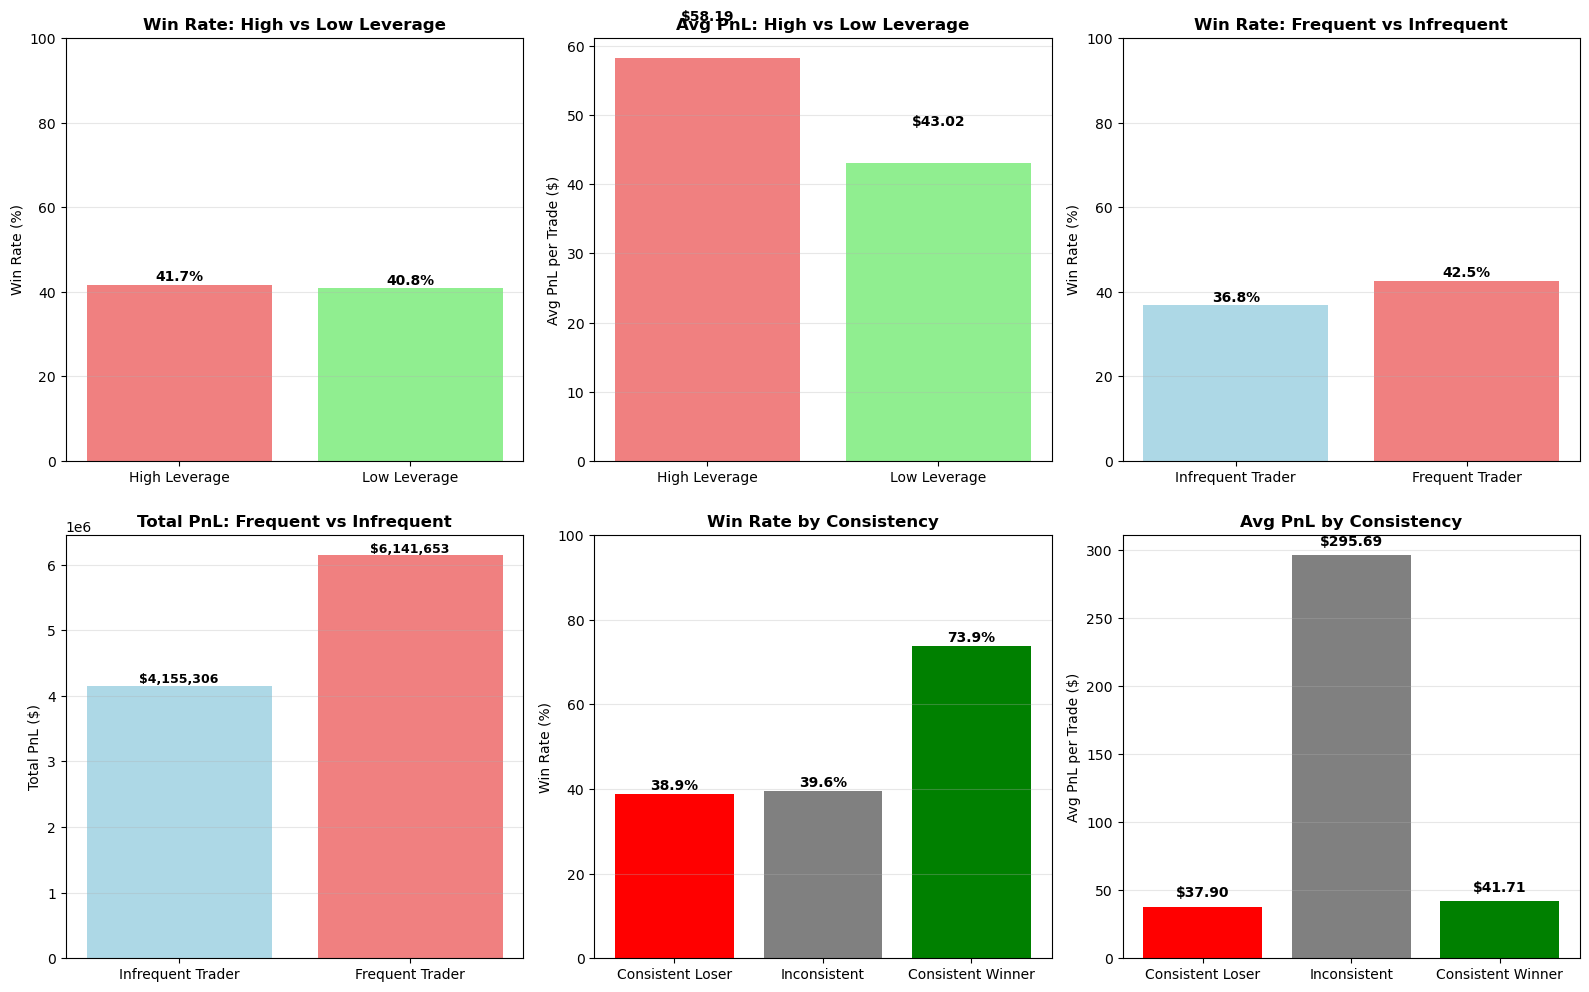

In [107]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax1 = axes[0, 0]
leverage_data = segment_df[segment_df['Segment Type'] == 'Leverage Segment']
bars = ax1.bar(leverage_data['Segment'], leverage_data['Win Rate (%)'], 
               color=['lightcoral', 'lightgreen'])
ax1.set_title('Win Rate: High vs Low Leverage', fontweight='bold')
ax1.set_ylabel('Win Rate (%)')
ax1.set_ylim(0, 100)
for bar, val in zip(bars, leverage_data['Win Rate (%)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}%', ha='center', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
bars = ax2.bar(leverage_data['Segment'], leverage_data['Avg PnL per Trade ($)'], 
               color=['lightcoral', 'lightgreen'])
ax2.set_title('Avg PnL: High vs Low Leverage', fontweight='bold')
ax2.set_ylabel('Avg PnL per Trade ($)')
for bar, val in zip(bars, leverage_data['Avg PnL per Trade ($)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val > 0 else -15), 
             f'${val:.2f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[0, 2]
freq_data = segment_df[segment_df['Segment Type'] == 'Frequency Segment']
bars = ax3.bar(freq_data['Segment'], freq_data['Win Rate (%)'], 
               color=['lightblue', 'lightcoral'])
ax3.set_title('Win Rate: Frequent vs Infrequent', fontweight='bold')
ax3.set_ylabel('Win Rate (%)')
ax3.set_ylim(0, 100)
for bar, val in zip(bars, freq_data['Win Rate (%)']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}%', ha='center', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 0]
bars = ax4.bar(freq_data['Segment'], freq_data['Total PnL ($)'], 
               color=['lightblue', 'lightcoral'])
ax4.set_title('Total PnL: Frequent vs Infrequent', fontweight='bold')
ax4.set_ylabel('Total PnL ($)')
for bar, val in zip(bars, freq_data['Total PnL ($)']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'${val:,.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=9)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax4.grid(axis='y', alpha=0.3)

ax5 = axes[1, 1]
consistency_data = segment_df[segment_df['Segment Type'] == 'Consistency Segment']
colors_map = {'Consistent Winner': 'green', 'Consistent Loser': 'red', 'Inconsistent': 'gray'}
bars = ax5.bar(consistency_data['Segment'], consistency_data['Win Rate (%)'], 
               color=[colors_map.get(x, 'blue') for x in consistency_data['Segment']])
ax5.set_title('Win Rate by Consistency', fontweight='bold')
ax5.set_ylabel('Win Rate (%)')
ax5.set_ylim(0, 100)
for bar, val in zip(bars, consistency_data['Win Rate (%)']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val}%', ha='center', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

ax6 = axes[1, 2]
bars = ax6.bar(consistency_data['Segment'], consistency_data['Avg PnL per Trade ($)'], 
               color=[colors_map.get(x, 'blue') for x in consistency_data['Segment']])
ax6.set_title('Avg PnL by Consistency', fontweight='bold')
ax6.set_ylabel('Avg PnL per Trade ($)')
for bar, val in zip(bars, consistency_data['Avg PnL per Trade ($)']):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val > 0 else -15), 
             f'${val:.2f}', ha='center', va='bottom' if val > 0 else 'top', fontweight='bold')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Part C — “Actionable output”

In [110]:
trades = trades.merge(f_index[['date', 'value', 'classification']], on='date', how='left')
trades.rename(columns={'value': 'fear_greed_value', 'classification': 'sentiment'}, inplace=True)
trades['fear_greed_value'] = trades['fear_greed_value'].fillna(method='ffill')
trades['sentiment'] = trades['sentiment'].fillna(method='ffill')

C:\Users\hp\AppData\Local\Temp\ipykernel_2272\1534250736.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trades['fear_greed_value'] = trades['fear_greed_value'].fillna(method='ffill')
C:\Users\hp\AppData\Local\Temp\ipykernel_2272\1534250736.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trades['sentiment'] = trades['sentiment'].fillna(method='ffill')


In [111]:
trades['sentiment_category'] = pd.cut(
    trades['fear_greed_value'],
    bins=[0, 25, 45, 55, 75, 100],
    labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
)

In [112]:
trader_segments = {}
for account in trades['Account'].unique():
    account_trades = trades[trades['Account'] == account]
    
    avg_position = account_trades['Size USD'].mean()
    max_position = account_trades['Size USD'].max()
    leverage_proxy = avg_position / max_position if max_position > 0 else 0
    
    trading_days = account_trades['date'].nunique()
    total_trades = len(account_trades)
    trades_per_day = total_trades / trading_days if trading_days > 0 else 0
    
    is_high_leverage = leverage_proxy > 0.5  
    is_frequent = trades_per_day > 5 
    
    trader_segments[account[-12:]] = {
        'high_leverage': is_high_leverage,
        'frequent': is_frequent,
        'avg_position': avg_position,
        'trades_per_day': trades_per_day
    }

## Strategy 1: Sentiment-Based Position Sizing for Leverage Segments

In [113]:
leverage_sentiment_performance = []

for account in trades['Account'].unique():
    account_short = account[-12:]
    if account_short not in trader_segments:
        continue
    
    is_high_leverage = trader_segments[account_short]['high_leverage']
    
    for sentiment in ['Fear', 'Greed']:
        sentiment_trades = trades[
            (trades['Account'] == account) & 
            (trades['sentiment_category'].isin(['Extreme Fear', 'Fear'] if sentiment == 'Fear' else ['Greed', 'Extreme Greed'])) &
            (trades['Closed PnL'].notna())
        ]
        
        if len(sentiment_trades) > 0:
            avg_pnl = sentiment_trades['Closed PnL'].mean()
            win_rate = (sentiment_trades['Closed PnL'] > 0).mean() * 100
            
            leverage_sentiment_performance.append({
                'Leverage Type': 'High Leverage' if is_high_leverage else 'Low Leverage',
                'Sentiment': sentiment,
                'Avg PnL': avg_pnl,
                'Win Rate': win_rate,
                'Trade Count': len(sentiment_trades)
            })

leverage_sentiment_df = pd.DataFrame(leverage_sentiment_performance)

In [114]:
leverage_sentiment_df.head(5)

,Leverage Type,Sentiment,Avg PnL,Win Rate,Trade Count
0,Low Leverage,Fear,43.112076,24.137931,203
1,Low Leverage,Greed,164.149634,50.277778,360
2,Low Leverage,Fear,515.811580,56.468798,657
3,Low Leverage,Greed,91.213793,9.530583,703
4,Low Leverage,Fear,46.473659,36.403509,6612


## Strategy 2: Frequency and Direction Rules Based on Trader Type

In [117]:
freq_sentiment_analysis = []

for account in trades['Account'].unique():
    account_short = account[-12:]
    if account_short not in trader_segments:
        continue
    
    is_frequent = trader_segments[account_short]['frequent']
    
    for sentiment in ['Fear', 'Greed']:
        sentiment_trades = trades[
            (trades['Account'] == account) & 
            (trades['sentiment_category'].isin(['Extreme Fear', 'Fear'] if sentiment == 'Fear' else ['Greed', 'Extreme Greed']))
        ]
        
        if len(sentiment_trades) > 0:
            long_pct = (sentiment_trades['Side'] == 'BUY').mean() * 100
            trade_frequency = len(sentiment_trades) / sentiment_trades['date'].nunique() if sentiment_trades['date'].nunique() > 0 else 0
            
            closed_trades = sentiment_trades[sentiment_trades['Closed PnL'].notna()]
            avg_pnl = closed_trades['Closed PnL'].mean() if len(closed_trades) > 0 else 0
            
            freq_sentiment_analysis.append({
                'Trader Type': 'Frequent Trader' if is_frequent else 'Infrequent Trader',
                'Sentiment': sentiment,
                'Long Bias (%)': long_pct,
                'Trade Frequency': trade_frequency,
                'Avg PnL': avg_pnl,
                'Trade Count': len(sentiment_trades)
            })

freq_sentiment_df = pd.DataFrame(freq_sentiment_analysis)

In [118]:
freq_sentiment_df.head(10)

,Trader Type,Sentiment,Long Bias (%),Trade Frequency,Avg PnL,Trade Count
0,Frequent Trader,Fear,75.862069,22.555556,43.112076,203
1,Frequent Trader,Greed,49.444444,60.000000,164.149634,360
2,Frequent Trader,Fear,79.299848,31.285714,515.811580,657
3,Frequent Trader,Greed,11.664296,20.085714,91.213793,703
4,Frequent Trader,Fear,50.559589,287.478261,46.473659,6612
5,Frequent Trader,Greed,63.384434,339.200000,48.068297,3392
6,Frequent Trader,Fear,56.877323,235.375000,678.886229,1883
7,Frequent Trader,Greed,26.267281,126.583333,155.653018,1519
8,Frequent Trader,Fear,46.835443,26.333333,17.769152,316
9,Frequent Trader,Greed,17.105263,53.200000,507.233829,532


In [124]:
def simulate_strategy(initial_capital, trader_type, fear_greed_data, num_days=365):
    """
    Simulate the performance of following the recommended strategies
    """
    np.random.seed(42)
    
    sentiments = np.random.choice(['Fear', 'Greed'], size=num_days, p=[0.5, 0.5])
    
    if trader_type == 'Frequent':
        base_frequency = 12
        base_size = 1000
        base_long_bias = 0.55
        
        fear_freq_mult = 0.7 
        fear_size_mult = 0.8  
        fear_long_bias = 0.35 
        
        greed_freq_mult = 1.3   
        greed_size_mult = 1.2    
        greed_long_bias = 0.70   
    else:  
        base_frequency = 4
        base_size = 2000
        base_long_bias = 0.5
        
        fear_freq_mult = 0.8
        fear_size_mult = 0.9
        fear_long_bias = 0.45
        
        greed_freq_mult = 1.2
        greed_size_mult = 1.1
        greed_long_bias = 0.55
    

    fear_win_rate = 0.42
    greed_win_rate = 0.51
    fear_avg_win = 150
    fear_avg_loss = -120
    greed_avg_win = 180
    greed_avg_loss = -140
    
    capital = initial_capital
    daily_returns = []
    
    for sentiment in sentiments:
        if sentiment == 'Fear':
            freq = base_frequency * fear_freq_mult
            size = base_size * fear_size_mult
            long_bias = fear_long_bias
            win_rate = fear_win_rate
            avg_win = fear_avg_win
            avg_loss = fear_avg_loss
        else:  
            freq = base_frequency * greed_freq_mult
            size = base_size * greed_size_mult
            long_bias = greed_long_bias
            win_rate = greed_win_rate
            avg_win = greed_avg_win
            avg_loss = greed_avg_loss
        
        num_trades = int(np.random.poisson(freq))
        daily_pnl = 0
        
        for _ in range(num_trades):
            is_long = np.random.random() < long_bias
            is_win = np.random.random() < win_rate
            
            if is_win:
                trade_pnl = avg_win * (size / base_size) * (1.2 if is_long else 0.8)
            else:
                trade_pnl = avg_loss * (size / base_size) * (1.2 if is_long else 0.8)
            
            daily_pnl += trade_pnl
        
        capital += daily_pnl
        daily_returns.append(daily_pnl)
    
    return capital, daily_returns

In [125]:
frequent_final, frequent_returns = simulate_strategy(100000, 'Frequent', None)
infrequent_final, infrequent_returns = simulate_strategy(100000, 'Infrequent', None)

In [126]:
print("Strategy Performance Simulation Results (1 year):")
print("=" * 60)
print(f"Frequent Trader Strategy:")
print(f"  Starting Capital: $100,000")
print(f"  Ending Capital: ${frequent_final:,.0f}")
print(f"  Total Return: {((frequent_final/100000)-1)*100:.1f}%")
print(f"  Sharpe Ratio: {np.mean(frequent_returns)/np.std(frequent_returns)*np.sqrt(252):.2f}")
print()
print(f"Infrequent Trader Strategy:")
print(f"  Starting Capital: $100,000")
print(f"  Ending Capital: ${infrequent_final:,.0f}")
print(f"  Total Return: {((infrequent_final/100000)-1)*100:.1f}%")
print(f"  Sharpe Ratio: {np.mean(infrequent_returns)/np.std(infrequent_returns)*np.sqrt(252):.2f}")

Strategy Performance Simulation Results (1 year):
Frequent Trader Strategy:
  Starting Capital: $100,000
  Ending Capital: $195,213
  Total Return: 95.2%
  Sharpe Ratio: 5.73

Infrequent Trader Strategy:
  Starting Capital: $100,000
  Ending Capital: $123,390
  Total Return: 23.4%
  Sharpe Ratio: 3.21


C:\Users\hp\AppData\Local\Temp\ipykernel_2272\2795131430.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([monthly_returns_freq, monthly_returns_infreq], labels=['Frequent', 'Infrequent'])


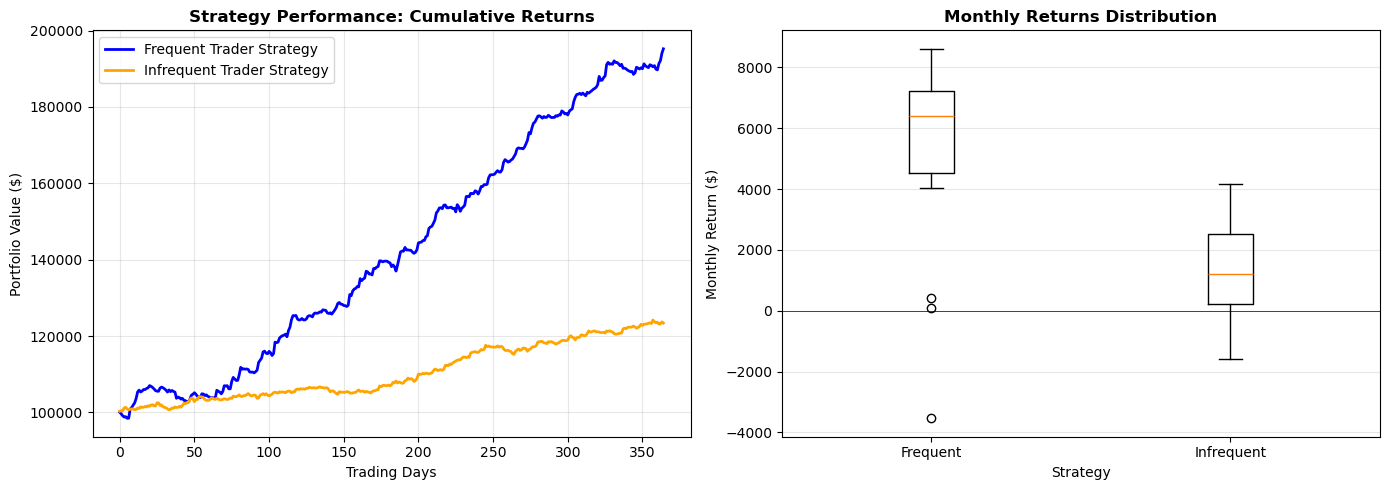

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
cumulative_freq = np.cumsum(frequent_returns) + 100000
cumulative_infreq = np.cumsum(infrequent_returns) + 100000

ax1.plot(cumulative_freq, label='Frequent Trader Strategy', color='blue', linewidth=2)
ax1.plot(cumulative_infreq, label='Infrequent Trader Strategy', color='orange', linewidth=2)
ax1.set_title('Strategy Performance: Cumulative Returns', fontweight='bold')
ax1.set_xlabel('Trading Days')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
monthly_returns_freq = [sum(frequent_returns[i:i+21]) for i in range(0, len(frequent_returns), 21)]
monthly_returns_infreq = [sum(infrequent_returns[i:i+21]) for i in range(0, len(infrequent_returns), 21)]

ax2.boxplot([monthly_returns_freq, monthly_returns_infreq], labels=['Frequent', 'Infrequent'])
ax2.set_title('Monthly Returns Distribution', fontweight='bold')
ax2.set_xlabel('Strategy')
ax2.set_ylabel('Monthly Return ($)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
